In [27]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Path to the Series Matrix file
file_path = '/kaggle/input/fshd-dataset/Dataset2_GSE36398_series_matrix (1).txt'  # Replace with the actual file path

# Initialize an empty list to store the lines after the matrix table begins
matrix_data = []

# Open the Series Matrix file
with open(file_path, 'rt') as file:
    is_matrix = False
    for line in file:
        # Look for the line that indicates the start of the matrix
        if line.startswith("!series_matrix_table_begin"):
            is_matrix = True
            continue  # Skip this line, the matrix starts after it
        elif line.startswith("!series_matrix_table_end"):
            break  # Stop when we reach the end of the matrix

        # If we are in the matrix part, collect the lines
        if is_matrix:
            matrix_data.append(line.strip())



In [28]:
headers = matrix_data[0].split('\t')

# The rest of the lines contain the data for each gene/probe
data = [line.split('\t') for line in matrix_data[1:]]

# Create the DataFrame
df = pd.DataFrame(data, columns=headers)

In [29]:
df.head()

,"""ID_REF""","""GSM892341""","""GSM892342""","""GSM892343""","""GSM892344""","""GSM892345""","""GSM892346""","""GSM892347""","""GSM892348""","""GSM892349""",...,"""GSM892381""","""GSM892382""","""GSM892383""","""GSM892384""","""GSM892385""","""GSM892386""","""GSM892387""","""GSM892388""","""GSM892389""","""GSM892390"""
0,7892501,2.69436,4.14421,3.71685,4.91865,4.36051,6.15274,4.87124,2.6812,2.37867,...,2.58022,2.34025,2.6575,2.32534,2.52095,2.52999,3.08851,2.95307,2.19638,2.92756
1,7892502,5.36362,4.82062,5.14681,4.96349,5.22542,5.08787,5.05183,4.9384,5.14289,...,4.77709,5.32276,5.22259,4.71483,4.47399,5.35785,4.44756,4.83425,4.86621,4.29354
2,7892503,3.29625,4.139,3.4495,4.45905,3.36257,3.93171,4.50758,4.3835,3.29511,...,3.70415,3.15909,3.59883,3.23366,3.66587,3.46491,2.6699,3.34483,3.29887,3.19826
3,7892504,9.32365,9.42975,9.2081,9.06239,9.25775,9.4629,9.71636,9.70411,9.59551,...,8.64995,9.05828,9.13113,8.85675,8.93359,8.8838,9.30212,9.28771,8.75881,8.86856
4,7892505,3.25822,3.99531,2.93149,3.77013,3.72848,4.47241,3.13487,3.40859,3.3599,...,3.27102,3.61036,3.01398,2.99226,3.50909,3.19207,3.21607,3.31852,3.61308,3.42225


In [30]:
df.columns = df.columns.str.replace('"', '')

In [31]:
df.shape

(33297, 51)

In [32]:
# Transpose the dataframe
df = df.T

# Set the first row as the header
df.columns = df.iloc[0]

# Create a new column 'sample_id' with the previous column headers
df['sample_id'] = df.index

# Drop the first row since it's now used as headers
df = df.drop(index=df.index[0])

# Reset index if necessary
df.reset_index(drop=True, inplace=True)
df.columns.name = None

df.head()

,7892501,7892502,7892503,7892504,7892505,7892506,7892507,7892508,7892509,7892510,...,8180410,8180411,8180412,8180413,8180414,8180415,8180416,8180417,8180418,sample_id
0,2.69436,5.36362,3.29625,9.32365,3.25822,3.85351,5.08983,4.32527,11.503,2.68308,...,10.12021,7.57741,7.62879,7.46366,6.58976,6.66664,6.04219,8.73181,7.35747,GSM892341
1,4.14421,4.82062,4.139,9.42975,3.99531,4.21746,5.75516,4.7584,11.19746,4.16306,...,10.19191,7.69751,7.45021,7.26517,6.17724,6.44513,6.29065,8.55077,7.53255,GSM892342
2,3.71685,5.14681,3.4495,9.2081,2.93149,4.22158,4.62311,4.91811,11.74478,3.42031,...,10.25091,7.40726,7.80967,7.59174,6.22361,6.8076,5.7994,8.7478,8.11136,GSM892343
3,4.91865,4.96349,4.45905,9.06239,3.77013,3.69635,5.32378,5.26901,11.50871,3.71582,...,10.3916,7.54428,7.49888,7.29813,6.37809,6.46073,6.12713,8.58399,6.58152,GSM892344
4,4.36051,5.22542,3.36257,9.25775,3.72848,3.53138,4.70359,5.28222,11.43595,4.81427,...,10.23121,7.62352,7.37203,7.1681,6.42264,6.86699,5.78777,8.88992,7.35455,GSM892345


In [33]:
data = {
    'sample_id': ['GSM892341', 'GSM892342', 'GSM892343', 'GSM892344', 'GSM892345', 
               'GSM892346', 'GSM892347', 'GSM892348', 'GSM892349', 'GSM892350',
               'GSM892351', 'GSM892352', 'GSM892353', 'GSM892354', 'GSM892355', 
               'GSM892356', 'GSM892357', 'GSM892358', 'GSM892359', 'GSM892360',
               'GSM892361', 'GSM892362', 'GSM892363', 'GSM892364', 'GSM892365',
               'GSM892366', 'GSM892367', 'GSM892368', 'GSM892369', 'GSM892370',
               'GSM892371', 'GSM892372', 'GSM892373', 'GSM892374', 'GSM892375',
               'GSM892376', 'GSM892377', 'GSM892378', 'GSM892379', 'GSM892380',
               'GSM892381', 'GSM892382', 'GSM892383', 'GSM892384', 'GSM892385',
               'GSM892386', 'GSM892387', 'GSM892388', 'GSM892389', 'GSM892390'],
    
    'Disease': ['FSHD', 'FSHD', 'Normal', 'Normal', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'FSHD', 'FSHD',
                'Normal', 'Normal', 'FSHD', 'FSHD', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'Normal', 'Normal',
                'FSHD', 'FSHD', 'Normal', 'Normal', 'FSHD', 
                'FSHD', 'Normal', 'Normal', 'FSHD', 'FSHD',
                'Normal', 'Normal', 'FSHD', 'FSHD', 'Normal', 
                'Normal', 'FSHD', 'FSHD', 'Normal', 'Normal',
                'FSHD', 'FSHD', 'FSHD', 'FSHD', 'Normal', 
                'Normal', 'FSHD', 'FSHD', 'Normal', 'Normal']
}

data_df = pd.DataFrame(data)

In [34]:
data_df

,sample_id,Disease
0,GSM892341,FSHD
1,GSM892342,FSHD
2,GSM892343,Normal
3,GSM892344,Normal
4,GSM892345,FSHD
5,GSM892346,FSHD
6,GSM892347,Normal
7,GSM892348,Normal
8,GSM892349,FSHD
9,GSM892350,FSHD


In [35]:
# Merging the dataframes on the 'ID_REF' column
df = pd.merge(df, data_df, on='sample_id', how='inner')

In [36]:
df[['sample_id', 'Disease']]

,sample_id,Disease
0,GSM892341,FSHD
1,GSM892342,FSHD
2,GSM892343,Normal
3,GSM892344,Normal
4,GSM892345,FSHD
5,GSM892346,FSHD
6,GSM892347,Normal
7,GSM892348,Normal
8,GSM892349,FSHD
9,GSM892350,FSHD


# Data Preprocessing

In [37]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Assuming 'target_column' is the binary target column in your dataframe
df['disease'] = label_encoder.fit_transform(df['Disease'])

In [38]:
X = df.drop(['Disease', 'sample_id'], axis = 1)
y = df[['disease']]

In [39]:
X.head()

,7892501,7892502,7892503,7892504,7892505,7892506,7892507,7892508,7892509,7892510,...,8180410,8180411,8180412,8180413,8180414,8180415,8180416,8180417,8180418,disease
0,2.69436,5.36362,3.29625,9.32365,3.25822,3.85351,5.08983,4.32527,11.503,2.68308,...,10.12021,7.57741,7.62879,7.46366,6.58976,6.66664,6.04219,8.73181,7.35747,0
1,4.14421,4.82062,4.139,9.42975,3.99531,4.21746,5.75516,4.7584,11.19746,4.16306,...,10.19191,7.69751,7.45021,7.26517,6.17724,6.44513,6.29065,8.55077,7.53255,0
2,3.71685,5.14681,3.4495,9.2081,2.93149,4.22158,4.62311,4.91811,11.74478,3.42031,...,10.25091,7.40726,7.80967,7.59174,6.22361,6.8076,5.7994,8.7478,8.11136,1
3,4.91865,4.96349,4.45905,9.06239,3.77013,3.69635,5.32378,5.26901,11.50871,3.71582,...,10.3916,7.54428,7.49888,7.29813,6.37809,6.46073,6.12713,8.58399,6.58152,1
4,4.36051,5.22542,3.36257,9.25775,3.72848,3.53138,4.70359,5.28222,11.43595,4.81427,...,10.23121,7.62352,7.37203,7.1681,6.42264,6.86699,5.78777,8.88992,7.35455,0


In [40]:
y.head()

,disease
0,0
1,0
2,1
3,1
4,0


## Train Test Split

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42, stratify = y)

In [42]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(40, 33298)
(40, 1)
(10, 33298)
(10, 1)


'sample_id' column contains alphaneumeric characters. For training the machine learning model we don't need the ID column. So we will drop it.

## Normalizing the Data

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


# Training the Models

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

# List of classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'k-NN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier()
}


Classifier: Random Forest


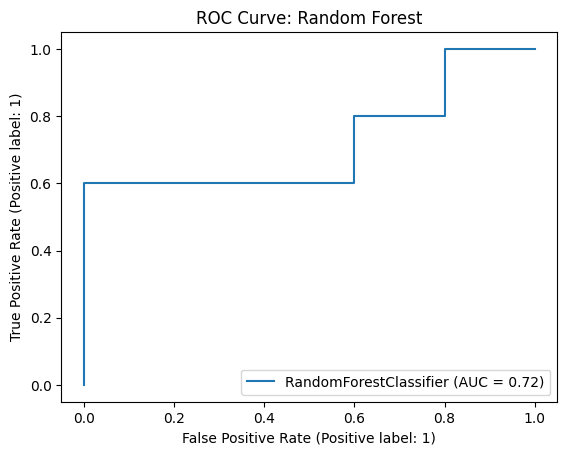

Accuracy: 0.5000
F1 Score: 0.4949
Recall: 0.5000
Confusion Matrix:
[[2 3]
 [2 3]]
ROC AUC Score: 0.7200

Classifier: SVM


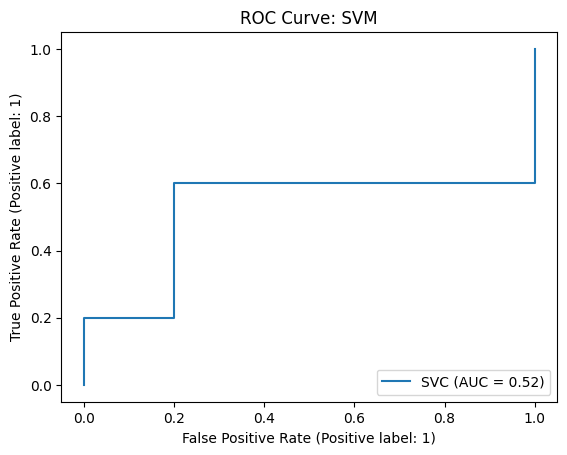

Accuracy: 0.3000
F1 Score: 0.2929
Recall: 0.3000
Confusion Matrix:
[[1 4]
 [3 2]]
ROC AUC Score: 0.5200

Classifier: k-NN


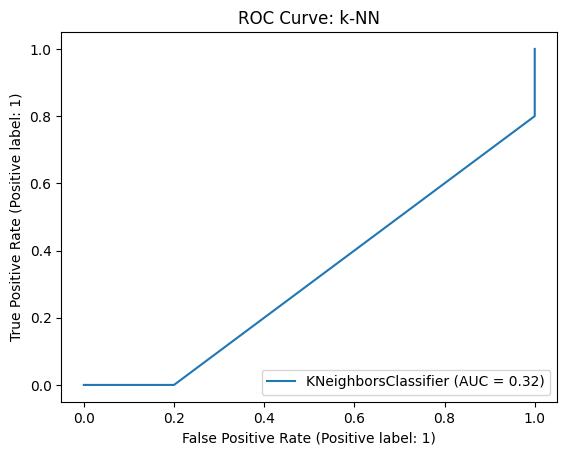

Accuracy: 0.4000
F1 Score: 0.3750
Recall: 0.4000
Confusion Matrix:
[[1 4]
 [2 3]]
ROC AUC Score: 0.3200

Classifier: Naive Bayes


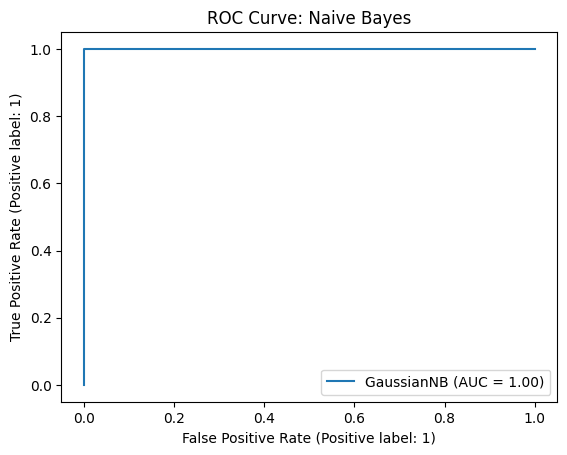

Accuracy: 1.0000
F1 Score: 1.0000
Recall: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
ROC AUC Score: 1.0000

Classifier: Logistic Regression


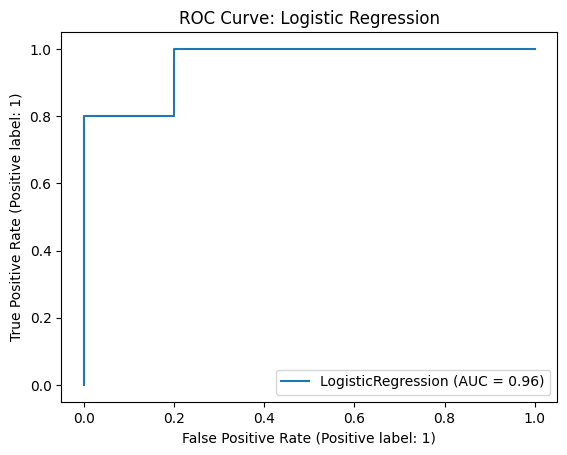

Accuracy: 0.8000
F1 Score: 0.7917
Recall: 0.8000
Confusion Matrix:
[[3 2]
 [0 5]]
ROC AUC Score: 0.9600

Classifier: Gradient Boosting


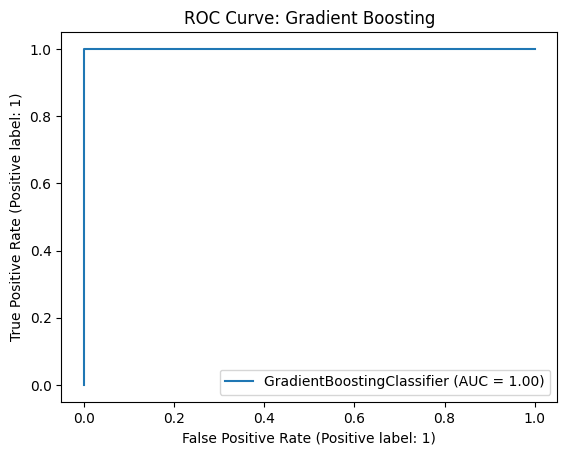

Accuracy: 1.0000
F1 Score: 1.0000
Recall: 1.0000
Confusion Matrix:
[[5 0]
 [0 5]]
ROC AUC Score: 1.0000


In [45]:
# Loop through classifiers
for name, clf in classifiers.items():
    print(f"\nClassifier: {name}")
    
    # Train the classifier
    clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Accuracy, F1, Recall
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # ROC AUC score
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        RocCurveDisplay.from_estimator(clf, X_test_scaled, y_test)
        plt.title(f"ROC Curve: {name}")
        plt.show()
    else:
        roc_auc = None
    
    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")


# Variational Auto Encoder

In [48]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# 3. VAE Architecture Adaptation for Microarray Data
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 4. Define the VAE Model
def create_vae(input_dim, latent_dim):
    # # Encoder
    # encoder_inputs = layers.Input(shape=(input_dim,))
    # h = layers.Dense(512, activation='relu')(encoder_inputs)
    # z_mean = layers.Dense(latent_dim, name="z_mean")(h)
    # z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
    # z = Sampling()([z_mean, z_log_var])
    
    # encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    
    # # Decoder
    # latent_inputs = layers.Input(shape=(latent_dim,))
    # h_decoded = layers.Dense(512, activation='relu')(latent_inputs)
    # decoder_outputs = layers.Dense(input_dim, activation='sigmoid')(h_decoded)
    
    # decoder = Model(latent_inputs, decoder_outputs, name="decoder")


    encoder_inputs = layers.Input(shape=(input_dim,))
    
    # Increase the number of layers and neurons
    h = layers.Dense(1024, activation='relu')(encoder_inputs)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(512, activation='relu')(h)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(256, activation='relu')(h)
    h = layers.Dropout(0.4)(h)
    h = layers.Dense(128, activation='relu')(h)
    h = layers.Dropout(0.4)(h)
    
    # Latent space
    z_mean = layers.Dense(latent_dim, name="z_mean")(h)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
    z = Sampling()([z_mean, z_log_var])
    
    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    
    # Decoder
    latent_inputs = layers.Input(shape=(latent_dim,))
    
    # Increase the number of layers and neurons in the decoder as well
    h_decoded = layers.Dense(128, activation='relu')(latent_inputs)
    h_decoded = layers.Dropout(0.4)(h_decoded)
    h_decoded = layers.Dense(256, activation='relu')(h_decoded)
    h_decoded = layers.Dropout(0.4)(h_decoded)
    h_decoded = layers.Dense(512, activation='relu')(h_decoded)
    h_decoded = layers.Dropout(0.4)(h_decoded)
    h_decoded = layers.Dense(1024, activation='relu')(h_decoded)
    h_decoded = layers.Dropout(0.4)(h_decoded)
    
    # Output layer
    decoder_outputs = layers.Dense(input_dim, activation='sigmoid')(h_decoded)
    
    decoder = Model(latent_inputs, decoder_outputs, name="decoder")
    
    # Full VAE model
    vae = VAE(encoder, decoder)
    
    return vae

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(
                tf.keras.losses.MSE(data, reconstruction), axis=-1))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    
    # def extract_features(self, data):
    #     # Use the encoder to obtain the latent space representations
    #     z_mean, _, _ = self.encoder.predict(data)
    #     return z_mean

    def extract_features(self, data):
        # Use the encoder to obtain the latent space representations
        _, _, z = self.encoder.predict(data)
        
        # Combine z_mean and scaled z_log_var
        #z_combined = tf.concat([z_mean, tf.exp(0.5 * z_log_var)], axis=-1).numpy()
        
        return z




In [49]:
import tensorflow as tf
import numpy as np


# Set hyperparameters
input_dim = X_train_scaled.shape[1]  # Number of features in your dataset
latent_dim = 500  # Size of the latent space
learning_rate = 5e-5  # Learning rate for the optimizer
batch_size = 16  # Batch size
num_epochs = 50  # Number of epochs

# Create the VAE model
vae = create_vae(input_dim=input_dim, latent_dim=latent_dim)

# Compile the VAE
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate))

# Define a custom data generator for batches
dataset = tf.data.Dataset.from_tensor_slices(X_train_scaled).shuffle(buffer_size=1024).batch(batch_size)

# Train the VAE
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    for step, batch_data in enumerate(dataset):
        metrics = vae.train_step(batch_data)
        
        # Optionally print step-level loss for debugging
        if step % 100 == 0:
            print(f"  Step {step}, Loss: {metrics['loss']:.4f}, "
                  f"Reconstruction Loss: {metrics['reconstruction_loss']:.4f}, "
                  f"KL Loss: {metrics['kl_loss']:.4f}")
            
    # Print epoch-level metrics
    print(f"Epoch {epoch + 1} completed: Loss: {metrics['loss']:.4f}, "
          f"Reconstruction Loss: {metrics['reconstruction_loss']:.4f}, "
          f"KL Loss: {metrics['kl_loss']:.4f}")


Epoch 1/50
  Step 0, Loss: 50.8562, Reconstruction Loss: 20.0628, KL Loss: 30.7934
Epoch 1 completed: Loss: 39.6622, Reconstruction Loss: 16.6559, KL Loss: 23.0063
Epoch 2/50
  Step 0, Loss: 37.5924, Reconstruction Loss: 17.5057, KL Loss: 20.0867
Epoch 2 completed: Loss: 33.9666, Reconstruction Loss: 16.6338, KL Loss: 17.3328
Epoch 3/50
  Step 0, Loss: 33.2103, Reconstruction Loss: 17.1899, KL Loss: 16.0204
Epoch 3 completed: Loss: 31.2005, Reconstruction Loss: 16.6105, KL Loss: 14.5900
Epoch 4/50
  Step 0, Loss: 30.7000, Reconstruction Loss: 17.0396, KL Loss: 13.6603
Epoch 4 completed: Loss: 28.7320, Reconstruction Loss: 16.5841, KL Loss: 12.1478
Epoch 5/50
  Step 0, Loss: 28.3064, Reconstruction Loss: 16.8139, KL Loss: 11.4925
Epoch 5 completed: Loss: 27.0217, Reconstruction Loss: 16.5558, KL Loss: 10.4658
Epoch 6/50
  Step 0, Loss: 26.6120, Reconstruction Loss: 16.6720, KL Loss: 9.9399
Epoch 6 completed: Loss: 25.6077, Reconstruction Loss: 16.5265, KL Loss: 9.0811
Epoch 7/50
  Step 

In [50]:
encoded_features_train = vae.extract_features(X_train_scaled)
encoded_features_test = vae.extract_features(X_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step



Classifier: Random Forest


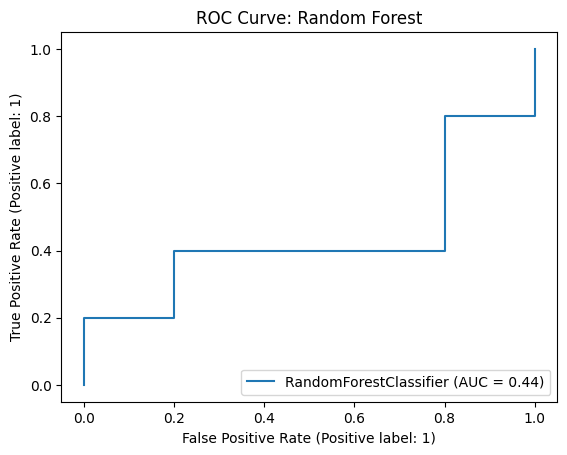

Training accuracy: 1.0000
Accuracy: 0.6000
F1 Score: 0.5833
Recall: 0.6000
Confusion Matrix:
[[4 1]
 [3 2]]
ROC AUC Score: 0.4400

Classifier: SVM


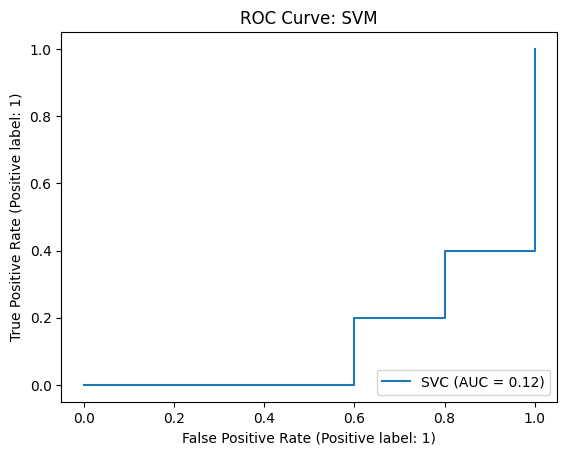

Training accuracy: 1.0000
Accuracy: 0.5000
F1 Score: 0.3333
Recall: 0.5000
Confusion Matrix:
[[5 0]
 [5 0]]
ROC AUC Score: 0.1200

Classifier: k-NN


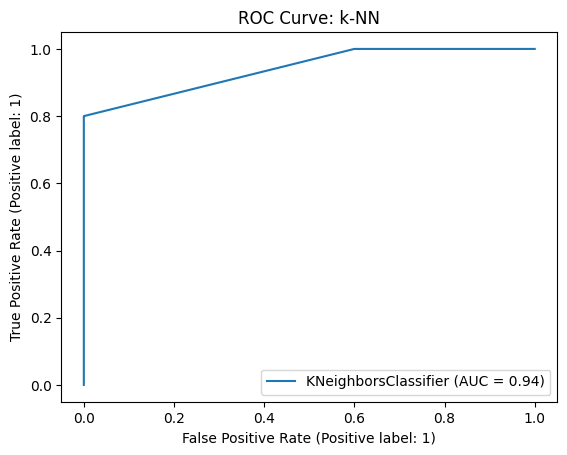

Training accuracy: 0.5750
Accuracy: 0.7000
F1 Score: 0.6703
Recall: 0.7000
Confusion Matrix:
[[2 3]
 [0 5]]
ROC AUC Score: 0.9400

Classifier: Naive Bayes


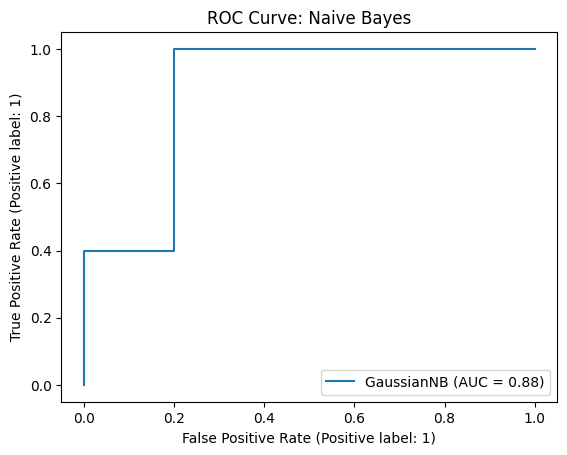

Training accuracy: 1.0000
Accuracy: 0.8000
F1 Score: 0.8000
Recall: 0.8000
Confusion Matrix:
[[4 1]
 [1 4]]
ROC AUC Score: 0.8800

Classifier: Logistic Regression


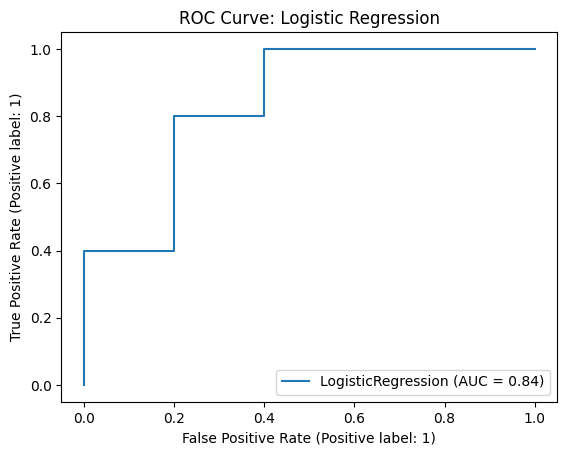

Training accuracy: 1.0000
Accuracy: 0.8000
F1 Score: 0.8000
Recall: 0.8000
Confusion Matrix:
[[4 1]
 [1 4]]
ROC AUC Score: 0.8400

Classifier: Gradient Boosting


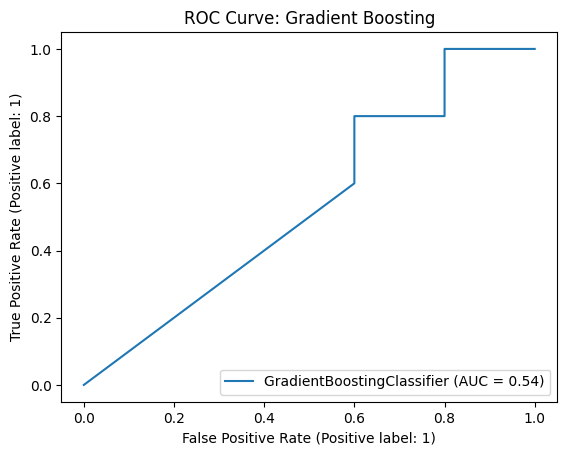

Training accuracy: 1.0000
Accuracy: 0.6000
F1 Score: 0.5238
Recall: 0.6000
Confusion Matrix:
[[1 4]
 [0 5]]
ROC AUC Score: 0.5400


In [51]:
# Loop through classifiers
for name, clf in classifiers.items():
    print(f"\nClassifier: {name}")
    
    # Train the classifier
    clf.fit(encoded_features_train, y_train)
    
    # Make predictions
    y_pred_train = clf.predict(encoded_features_train)
    y_pred_test = clf.predict(encoded_features_test)
    y_prob = clf.predict_proba(encoded_features_test)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Accuracy, F1, Recall
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_test)
    
    # ROC AUC score
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)  # Use probabilities for ROC AUC
        RocCurveDisplay.from_estimator(clf, encoded_features_test, y_test)
        plt.title(f"ROC Curve: {name}")
        plt.show()
    else:
        roc_auc = None
    
    # Print metrics
    print(f"Training accuracy: {accuracy_train:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    if roc_auc is not None:
        print(f"ROC AUC Score: {roc_auc:.4f}")
